# Capítulo 5 — Estabilidade Atmosférica: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | diagrama termodinâmico do zero + Skew-T com parcela | NumPy, `MetPy` |
| 2 | oscilador de Brunt–Väisälä (EDO com amortecimento) | `scipy.solve_ivp` |
| 3 | estabilidade estática **não local** (algoritmo do Stull) | NumPy |
| 4 | perfil do número de Richardson: caçando turbulência | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap05_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

Rd, Cp, g = 287.0, 1004.0, 9.8
Lv, Rv, eps = 2.5e6, 461.0, 0.622
e0, T00 = 0.6113, 273.15           # kPa, K (Clausius-Clapeyron, Cap. 4)
Gamma_d = g/Cp

## Caso 1 — Construindo o diagrama termodinâmico (e depois usando o oficial)

As três famílias de réguas num diagrama $T$–$\ln P$:
- **adiabáticas secas**: $T(P) = \theta\,(P/P_0)^{R_d/c_p}$ (Cap. 3);
- **isoumas**: curvas de $r_s$ constante via Clausius–Clapeyron (Cap. 4);
- (as adiabáticas úmidas ficam para o MetPy — exigem integração numérica).

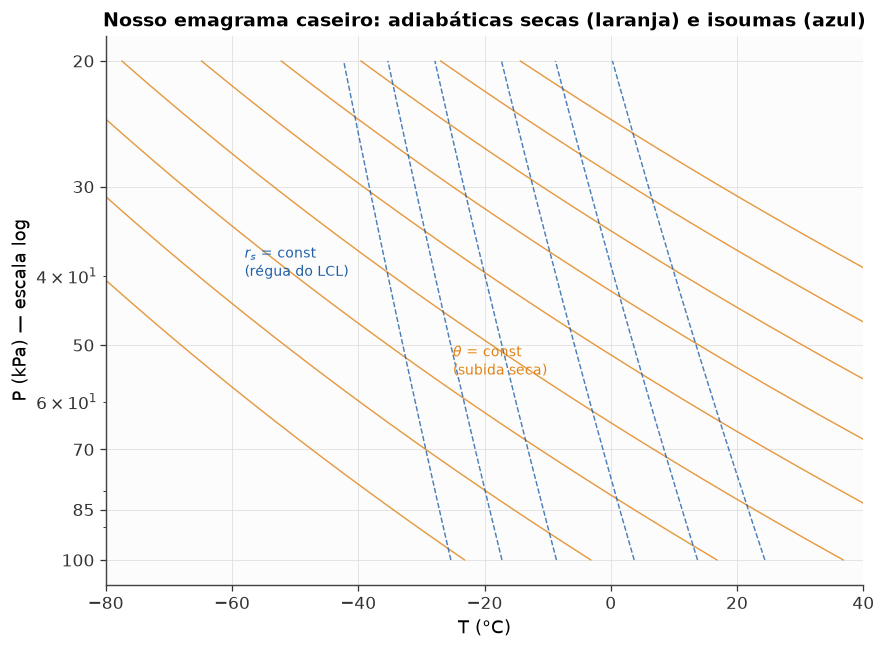

In [2]:
P = np.linspace(100, 20, 200)          # kPa

def T_adiab(theta, P):
    return theta*(P/100.0)**(Rd/Cp)

def T_isouma(rs, P):
    """T em que r_s(T,P) = rs: inverte Clausius-Clapeyron (rs em kg/kg)."""
    e = rs*P/(eps + rs)
    return 1.0/(1.0/T00 - (Rv/Lv)*np.log(e/e0))

fig, ax = plt.subplots(figsize=(8.5, 6.2))
for theta in np.arange(250, 411, 20):
    ax.plot(T_adiab(theta, P) - 273.15, P, color=CORES['laranja'], lw=0.9,
            alpha=0.8)
for rs in [0.5e-3, 1e-3, 2e-3, 5e-3, 10e-3, 20e-3]:
    ax.plot(T_isouma(rs, P) - 273.15, P, '--', color=CORES['azul'], lw=0.9,
            alpha=0.8)
ax.set_yscale('log'); ax.invert_yaxis()
ax.set_yticks([100, 85, 70, 50, 30, 20])
ax.set_yticklabels(['100', '85', '70', '50', '30', '20'])
ax.set(xlim=(-80, 40), xlabel='T (°C)', ylabel='P (kPa) — escala log',
       title='Nosso emagrama caseiro: adiabáticas secas (laranja) e isoumas (azul)')
ax.annotate('$\\theta$ = const\n(subida seca)', xy=(-25, 55), fontsize=9,
            color=CORES['laranja'])
ax.annotate('$r_s$ = const\n(régua do LCL)', xy=(-58, 40), fontsize=9,
            color=CORES['azul'])
plt.show()

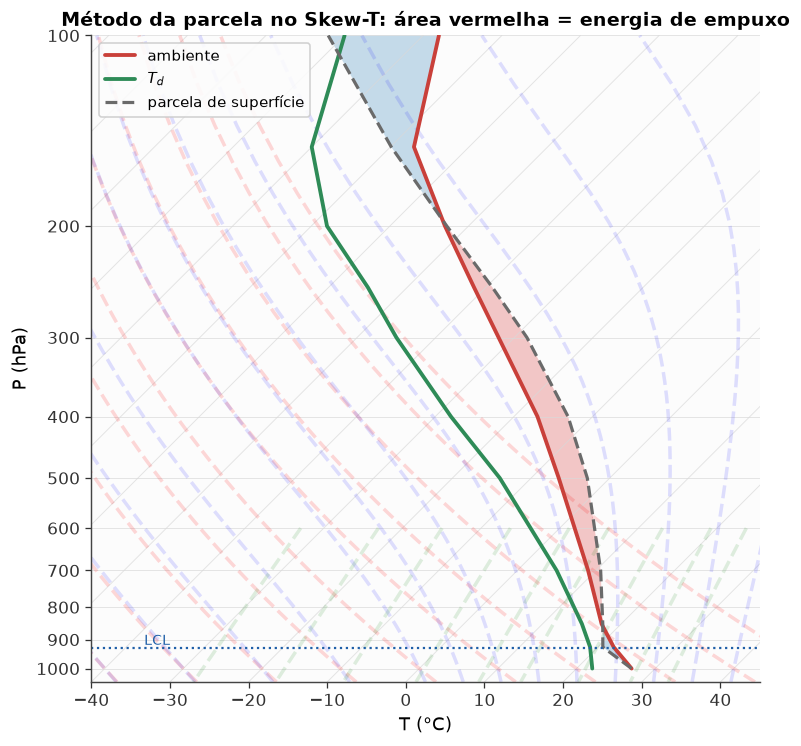

Área positiva (CAPE, prévia do Cap. 14): 1244 J/kg | CIN: -21 J/kg


In [3]:
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT

# sondagem tropical do curso
P_s  = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]) * units.hPa
T_s  = np.array([27.0, 22.0, 17.5, 9.0, -6.5, -17.0, -32.0, -41.5, -53.0, -67.0, -78.0]) * units.degC
Td_s = np.array([22.0, 19.0, 15.0, 5.0, -14.0, -28.0, -45.0, -55.0, -68.0, -80.0, -90.0]) * units.degC

parcela = mpcalc.parcel_profile(P_s, T_s[0], Td_s[0]).to('degC')
cape, cin = mpcalc.cape_cin(P_s, T_s, Td_s, parcela)

fig = plt.figure(figsize=(7.5, 7.5))
skew = SkewT(fig, rotation=45)
skew.plot(P_s, T_s, color=CORES['vermelho'], lw=2.4, label='ambiente')
skew.plot(P_s, Td_s, color=CORES['verde'], lw=2.4, label='$T_d$')
skew.plot(P_s, parcela, color=CORES['cinza'], lw=2.0, ls='--',
          label='parcela de superfície')
skew.shade_cape(P_s, T_s, parcela, alpha=0.25)
skew.shade_cin(P_s, T_s, parcela, alpha=0.25)
p_lcl, T_lcl = mpcalc.lcl(P_s[0], T_s[0], Td_s[0])
skew.ax.axhline(p_lcl.to('hPa').magnitude, color=CORES['azul'], ls=':', lw=1.4)
skew.ax.text(-38, p_lcl.to('hPa').magnitude - 12, 'LCL', color=CORES['azul'],
             fontsize=9)
skew.plot_dry_adiabats(alpha=0.15, color=CORES['laranja'])
skew.plot_moist_adiabats(alpha=0.12, color=CORES['verde'])
skew.plot_mixing_lines(alpha=0.12, color=CORES['azul'])
skew.ax.set_ylim(1050, 100); skew.ax.set_xlim(-40, 45)
skew.ax.set_xlabel('T (°C)'); skew.ax.set_ylabel('P (hPa)')
skew.ax.set_title('Método da parcela no Skew-T: área vermelha = energia de empuxo')
skew.ax.legend(loc='upper left')
plt.show()
print(f'Área positiva (CAPE, prévia do Cap. 14): {cape.magnitude:.0f} J/kg | '
      f'CIN: {cin.magnitude:.0f} J/kg')

## Caso 2 — A mola atmosférica: oscilador de Brunt–Väisälä

$$\ddot z' = -N^2 z' - \frac{1}{\tau}\dot z',\qquad N^2 = \frac{g}{\theta_v}\frac{d\theta_v}{dz}$$

Parcela deslocada 100 m para cima numa troposfera padrão ($\Gamma = 6{,}5$ K/km) — oscila com período $2\pi/N$; um arrasto fraco amortece.

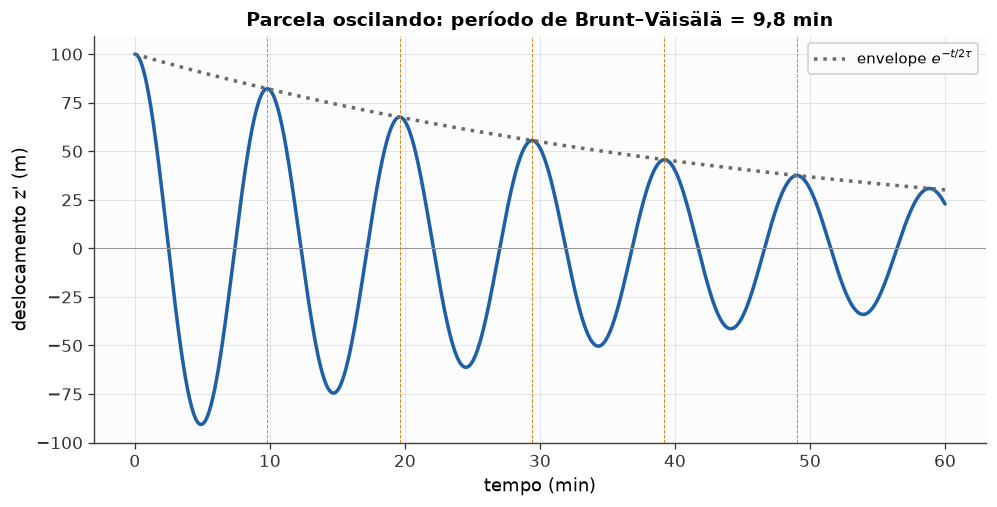

N = 10.7 mHz; período teórico 9.80 min | medido 9.81 min
Espaçamento de nuvens em faixa com vento de 10 m/s: 5.9 km


In [4]:
Tv = 280.0
N2 = (g/Tv)*(-6.5e-3 + Gamma_d)      # (dTv/dz + Γd)·g/Tv
N = np.sqrt(N2)
P_BV = 2*np.pi/N
tau = 25*60.0                         # tempo de amortecimento: 25 min

sol = solve_ivp(lambda t, y: [y[1], -N2*y[0] - y[1]/tau],
                [0, 3600], [100.0, 0.0], dense_output=True, rtol=1e-9)
t = np.linspace(0, 3600, 800)
z, w = sol.sol(t)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(t/60, z, color=CORES['azul'])
ax.plot(t/60, 100*np.exp(-t/(2*tau)), ':', color=CORES['cinza'],
        label='envelope $e^{-t/2\\tau}$')
ax.axhline(0, color='#999999', lw=0.7)
for k in range(1, 6):
    ax.axvline(k*P_BV/60, color=CORES['laranja'], lw=0.6, ls='--')
ax.set(xlabel='tempo (min)', ylabel="deslocamento z' (m)",
       title=f'Parcela oscilando: período de Brunt–Väisälä = {P_BV/60:.1f} min'.replace('.', ','))
ax.legend()
plt.show()

picos = t[1:-1][(z[1:-1] > z[:-2]) & (z[1:-1] > z[2:])]
print(f'N = {N*1e3:.1f} mHz; período teórico {P_BV/60:.2f} min | '
      f'medido {np.mean(np.diff(picos))/60:.2f} min')
print('Espaçamento de nuvens em faixa com vento de 10 m/s: '
      f'{10*P_BV/1e3:.1f} km')

## Caso 3 — Estabilidade não local: o algoritmo do Stull

Perfil de tarde convectiva: camada superadiabática colada ao chão, camada quase neutra até 1,5 km, inversão acima. O critério **local** olha só o gradiente; o **não local** levanta parcelas e vê até onde chegam.

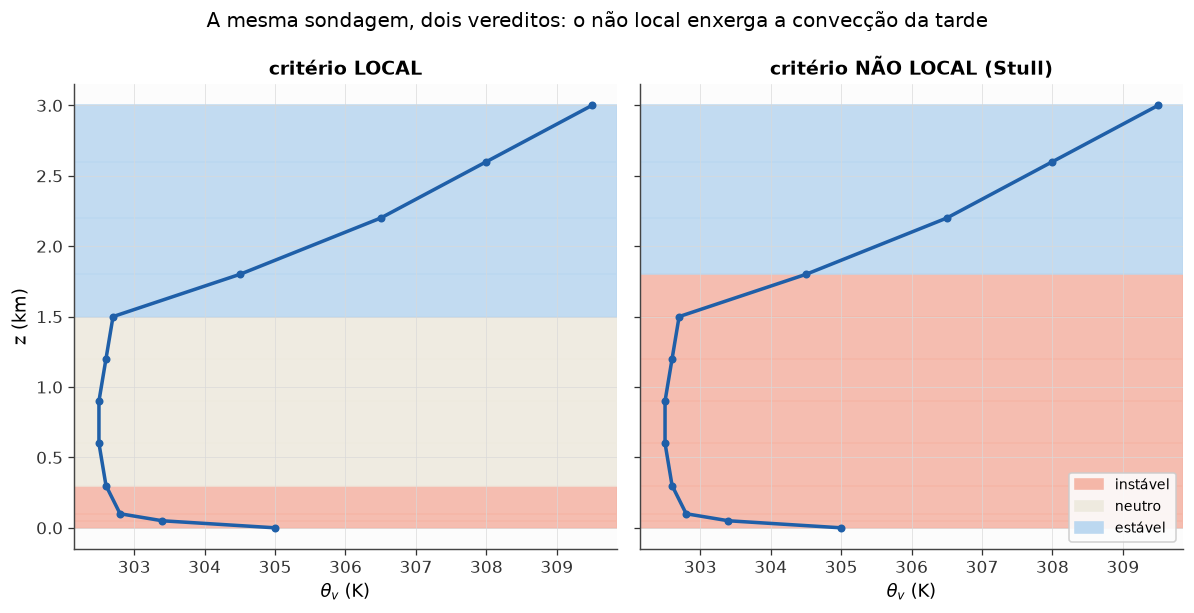

0.00–0.05 km: local=instável  não-local=instável 
0.05–0.10 km: local=instável  não-local=instável 
0.10–0.30 km: local=instável  não-local=instável 
0.30–0.60 km: local=neutro    não-local=instável   ← diferem!
0.60–0.90 km: local=neutro    não-local=instável   ← diferem!
0.90–1.20 km: local=neutro    não-local=instável   ← diferem!
1.20–1.50 km: local=neutro    não-local=instável   ← diferem!
1.50–1.80 km: local=estável   não-local=instável   ← diferem!
1.80–2.20 km: local=estável   não-local=estável  
2.20–2.60 km: local=estável   não-local=estável  
2.60–3.00 km: local=estável   não-local=estável  


In [5]:
z_km = np.array([0.0, 0.05, 0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.2, 2.6, 3.0])
thv  = np.array([305.0, 303.4, 302.8, 302.6, 302.5, 302.5, 302.6, 302.7,
                 304.5, 306.5, 308.0, 309.5])

def classifica_local(z, thv):
    dthv = np.diff(thv)/np.diff(z)
    rot = np.where(dthv < -0.4, 'instável', np.where(dthv > 0.4, 'estável', 'neutro'))
    return rot

def classifica_nao_local(z, thv):
    """Stull §5.6.1: sobe/desce parcelas de cada nível até o repouso;
    camadas atravessadas por alguma parcela = instáveis não locais."""
    atravessada = np.zeros(len(z)-1, bool)
    for i in range(len(z)):
        # parcela do nível i conserva thv[i]; sobe enquanto thv_parc >= thv_amb
        if i < len(z)-1 and thv[i] >= thv[i+1] - 1e-9:      # sobe
            j = i
            while j < len(z)-1 and thv[i] >= thv[j+1] - 1e-9:
                atravessada[j] = True; j += 1
        if i > 0 and thv[i] <= thv[i-1] + 1e-9:              # desce
            j = i
            while j > 0 and thv[i] <= thv[j-1] + 1e-9:
                atravessada[j-1] = True; j -= 1
    local = classifica_local(z, thv)
    return np.where(atravessada, 'instável', local)

rot_loc = classifica_local(z_km, thv)
rot_nl  = classifica_nao_local(z_km, thv)

cores_cls = {'instável': '#f5b7a8', 'neutro': '#eeeadf', 'estável': '#bcd8f0'}
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5.4), sharey=True)
for ax, rot, titulo in [(axs[0], rot_loc, 'critério LOCAL'),
                        (axs[1], rot_nl, 'critério NÃO LOCAL (Stull)')]:
    for i in range(len(z_km)-1):
        ax.axhspan(z_km[i], z_km[i+1], color=cores_cls[rot[i]], alpha=0.9,
                   zorder=0)
    ax.plot(thv, z_km, 'o-', color=CORES['azul'], ms=4)
    ax.set(xlabel='$\\theta_v$ (K)', title=titulo)
axs[0].set_ylabel('z (km)')
import matplotlib.patches as mpatches
axs[1].legend(handles=[mpatches.Patch(color=c, label=l)
                       for l, c in cores_cls.items()], loc='lower right',
              fontsize=9)
fig.suptitle('A mesma sondagem, dois vereditos: o não local enxerga a convecção da tarde')
fig.tight_layout(); plt.show()

for i in range(len(z_km)-1):
    marca = '  ← diferem!' if rot_loc[i] != rot_nl[i] else ''
    print(f'{z_km[i]:.2f}–{z_km[i+1]:.2f} km: local={rot_loc[i]:9s} '
          f'não-local={rot_nl[i]:9s}{marca}')

## Caso 4 — Número de Richardson: caçando turbulência de céu claro

$$Ri = \frac{N^2}{(\Delta U/\Delta z)^2 + (\Delta V/\Delta z)^2},\qquad Ri_c = 0{,}25$$

Sondagem estável + um jato de 60 m/s em 10 km: onde o cisalhamento vence a estratificação?

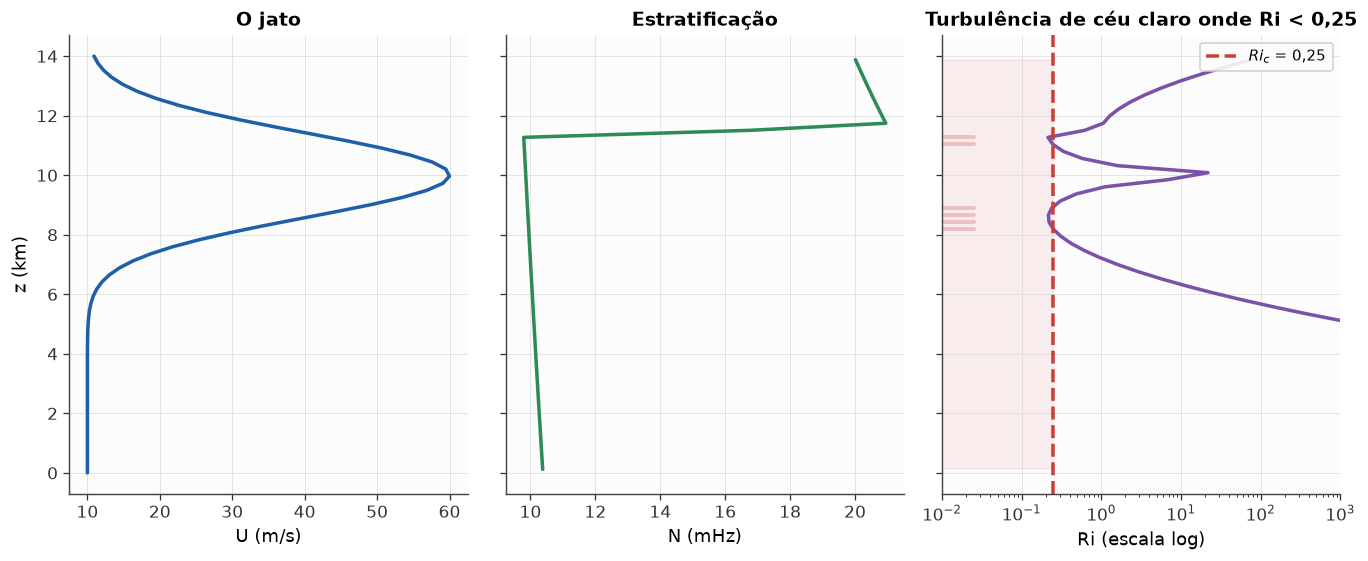

camadas turbulentas: 8.2–11.3 km (flancos do jato — onde os aviões sacodem)


In [6]:
z = np.linspace(0, 14e3, 60)
# perfil térmico: troposfera padrão + tropopausa a 11,5 km
thv_p = 300 + 3.3e-3*z + np.where(z > 11.5e3, 12e-3*(z - 11.5e3), 0.0)
# jato: máximo de 60 m/s em 10 km, largura 2 km
U = 10 + 50*np.exp(-((z - 10e3)/2000.0)**2)

zm   = 0.5*(z[1:] + z[:-1])
N2_p = g/(0.5*(thv_p[1:]+thv_p[:-1]))*np.diff(thv_p)/np.diff(z)
S2   = (np.diff(U)/np.diff(z))**2
Ri   = N2_p/np.maximum(S2, 1e-12)

fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
axs[0].plot(U, z/1e3, color=CORES['azul'])
axs[0].set(xlabel='U (m/s)', ylabel='z (km)', title='O jato')
axs[1].plot(np.sqrt(N2_p)*1e3, zm/1e3, color=CORES['verde'])
axs[1].set(xlabel='N (mHz)', title='Estratificação')
axs[2].semilogx(Ri, zm/1e3, color=CORES['roxo'])
axs[2].axvline(0.25, color=CORES['vermelho'], ls='--', label='$Ri_c$ = 0,25')
axs[2].fill_betweenx(zm/1e3, 1e-3, 0.25, color=CORES['vermelho'], alpha=0.08)
turb = Ri < 0.25
for zi in zm[turb]:
    axs[2].axhline(zi/1e3, color=CORES['vermelho'], lw=2.5, alpha=0.25,
                   xmax=0.08)
axs[2].set(xlabel='Ri (escala log)', xlim=(1e-2, 1e3),
           title='Turbulência de céu claro onde Ri < 0,25')
axs[2].legend(loc='upper right')
fig.tight_layout(); plt.show()
if turb.any():
    print(f'camadas turbulentas: {zm[turb].min()/1e3:.1f}–{zm[turb].max()/1e3:.1f} km '
          '(flancos do jato — onde os aviões sacodem)')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap05_solucoes.ipynb`**.

**N1** — Refaça o oscilador do Caso 2 para a estratosfera isotérmica ($N^2 = g\,\Gamma_d/T$) e para uma camada neutra ($N^2 = 0$); interprete os três comportamentos. Com $\tau = 25$ min, quantas oscilações completas a parcela troposférica executa antes da amplitude cair a 1/e?

**N2** — Acrescente ao emagrama caseiro do Caso 1 a trajetória de uma parcela de superfície ($T = 27$ °C, $T_d = 22$ °C, $P = 100$ kPa): adiabática seca até o LCL (interseção com a isouma de $r$ da parcela) e marque o ponto.

**N3** — Aplique `classifica_nao_local` ao perfil noturno `thv_noite` (fornecido abaixo) e explique por que a inversão de superfície muda tudo em relação ao Caso 3.

**N4** — No Caso 4, encontre numericamente o pico de vento do jato a partir do qual aparece a primeira camada com $Ri < 0{,}25$ (varra $U_{max}$ de 20 a 80 m/s).

In [7]:
# N1 — sua solução aqui


In [8]:
# N2 — sua solução aqui


In [9]:
# N3 — sua solução aqui. Perfil noturno (inversão de radiação na superfície):
z_noite   = np.array([0.0, 0.05, 0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.2])
thv_noite = np.array([296.0, 298.5, 300.0, 301.2, 302.0, 302.3, 302.5,
                      302.7, 304.5, 306.5])


In [10]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*